In [1]:
from dotenv import load_dotenv
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
import os
import requests
from langchain.agents import Tool
import nest_asyncio
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
import textwrap
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
import gradio as gr

In [2]:
load_dotenv(override=True)

True

In [3]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(message: str):
    """ Send a push notification to the user """
    requests.post(url=pushover_url, data={"token": pushover_token, "user": pushover_user, "message": message})

send_push_notification_tool = Tool(
    name="send_push_notification",
    func=push,
    description="Useful when soemone want to send a push notification"
)

In [4]:
send_push_notification_tool

Tool(name='send_push_notification', description='Useful when soemone want to send a push notification', func=<function push at 0x0000028A0E79EB60>)

In [5]:
nest_asyncio.apply()

In [6]:
async_browser = create_async_playwright_browser(headless=False)
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [7]:
for tool in tools:
    print(f"{tool.name}={tool}")

click_element=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
navigate_browser=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
previous_webpage=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
extract_text=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
extract_hyperlinks=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
get_elements=async_browser=<Browser type=<BrowserT

In [9]:
tool_dict = {tool.name: tool for tool in tools}
navigate_tool = tool_dict.get("navigate_browser")
extract_text_tool = tool_dict.get("extract_text")

await navigate_tool.arun({"url": "https://www.cnn.com"})
text = await extract_text_tool.arun({})

In [11]:
print(textwrap.fill(text))

Breaking News, Latest News and Videos | CNN CNN values your feedback
1. How relevant is this ad to you? 2. Did you encounter any technical
issues? No Video player was slow to load content Video content never
loaded Ad froze or did not finish loading Video content did not start
after ad Audio on ad was too loud Other issues Ad never loaded Ad
prevented/slowed the page from loading Content moved around while ad
loaded Ad was repetitive to ads I've seen previously Other issues
Cancel Submit Thank You! Your effort and contribution in providing
this feedback is much
appreciated. Close Ad Feedback Close icon US World Politics Business
Health Entertainment Style Travel Sports Science Climate Weather
Ukraine-Russia War Israel-Hamas War Games More US World Politics
Business Health Entertainment Style Travel Sports Science Climate
Weather Ukraine-Russia War Israel-Hamas War Games Watch Listen Live TV
Subscribe Sign in My Account Settings Newsletters Topics you follow
Sign out Your CNN account Si

In [12]:
tools.append(send_push_notification_tool)

In [13]:
for tool in tools:
    print(f"{tool.name}={tool}")

click_element=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
navigate_browser=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
previous_webpage=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
extract_text=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
extract_hyperlinks=async_browser=<Browser type=<BrowserType name=chromium executable_path=C:\Users\Admin\AppData\Local\ms-playwright\chromium-1187\chrome-win\chrome.exe> version=140.0.7339.16>
get_elements=async_browser=<Browser type=<BrowserT

In [14]:
# Step 1: Define the State class
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Step 2: Create graph builder using the state class
graph_builder = StateGraph(State)

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools=tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(input=state["messages"])]}

# Step 3: Create nodes
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4: Create edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")

memory = MemorySaver()

# Step 5: Compile graph builder
graph = graph_builder.compile(checkpointer=memory)

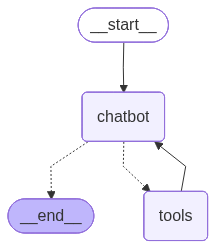

In [15]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
config = {"configurable": {"thread_id": "10"}}

async def chat(user_input: str, history):
    result = await graph.ainvoke(input={"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
